In [ ]:
# Cella 1: Importazione librerie
import pandas as pd
import numpy as np
import re
import collections
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Configurazione del device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [ ]:
# Cella 2: Caricamento e Feature Engineering

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv')
df = df.dropna(subset=['Aboard', 'Fatalities']).reset_index(drop=True)

# Target
df['Mortality_Rate'] = df['Fatalities'] / df['Aboard']
df['Is_Catastrophic'] = (df['Mortality_Rate'] >= 0.80).astype(int)

# Feature Ingegneria: Anno e Mese
df['Date_Parsed'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date_Parsed'].dt.year.fillna(df['Date_Parsed'].dt.year.median())
df['Month'] = df['Date_Parsed'].dt.month.fillna(6) # Giugno come fallback

df['Summary'] = df['Summary'].fillna('unknown').astype(str).str.lower()

# Ora abbiamo 3 feature tabulari
features_tabular = df[['Aboard', 'Year', 'Month']].values
texts = df['Summary'].values
targets = df['Is_Catastrophic'].values

scaler = StandardScaler()
features_tabular_scaled = scaler.fit_transform(features_tabular)

print(f"Dataset caricato. Righe totali: {len(df)}")
print(f"Catastrofici: {sum(targets)} | Contenuti: {len(targets) - sum(targets)}")

Dataset caricato. Righe totali: 4949
Catastrofici: 3634 | Contenuti: 1315


In [ ]:
# Cella 3: Tokenizzazione e Vocabolario Custom

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

word_counts = collections.Counter()
for text in texts:
    word_counts.update(clean_text(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
MAX_LEN = 60 # Aumentato per catturare più contesto

def text_to_indices(text, vocab, max_len):
    tokens = clean_text(text)
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    if len(indices) > max_len:
        indices = indices[:max_len]
    else:
        indices = indices + [vocab["<PAD>"]] * (max_len - len(indices))
    return indices

encoded_texts = np.array([text_to_indices(t, vocab, MAX_LEN) for t in texts])
print(f"Dimensione vocabolario: {VOCAB_SIZE} parole. Max Length: {MAX_LEN}")

Dimensione vocabolario: 5249 parole. Max Length: 60


In [ ]:
# Cella 4: Generazione Dataset e Dataloaders

X_tab_train, X_tab_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    features_tabular_scaled, encoded_texts, targets, test_size=0.2, random_state=42, stratify=targets
)

class MultimodalDataset(Dataset):
    def __init__(self, tabular, texts, targets):
        self.tabular = torch.tensor(tabular, dtype=torch.float32)
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.tabular[idx], self.texts[idx], self.targets[idx]

train_dataset = MultimodalDataset(X_tab_train, X_txt_train, y_train)
val_dataset = MultimodalDataset(X_tab_val, X_txt_val, y_val)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Cella 5: Architettura con Self-Attention e Bidirezionalità

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_outputs):
        # Calcola i pesi di attenzione per ogni parola
        attn_weights = F.softmax(self.attention(lstm_outputs), dim=1)
        # Moltiplica e somma (Estrae il vettore di contesto concentrato sulle parole chiave)
        context_vector = torch.sum(attn_weights * lstm_outputs, dim=1)
        return context_vector

class AirplaneCrashProNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, lstm_hidden_dim, tabular_dim):
        super(AirplaneCrashProNet, self).__init__()

        # Ramo Testo: Embeddings + Bi-LSTM + Attention
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, lstm_hidden_dim, batch_first=True, bidirectional=True)
        self.attention = Attention(lstm_hidden_dim * 2) # *2 perché è bidirezionale

        # Ramo Tabulare
        self.tabular_block = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # Fusione e Classificazione
        fusion_dim = (lstm_hidden_dim * 2) + 16
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, tabular_input, text_input):
        embedded = self.embedding(text_input)
        lstm_out, _ = self.lstm(embedded)
        text_features = self.attention(lstm_out) # Usa l'Attention invece dell'ultimo hidden state

        tabular_features = self.tabular_block(tabular_input)
        fused_features = torch.cat((text_features, tabular_features), dim=1)

        logits = self.classifier(fused_features)
        return logits.squeeze(1)

EMBED_DIM = 100 # Aumentato
LSTM_HIDDEN = 64 # Aumentato
TABULAR_DIM = 3 # Aboard, Year, Month

model = AirplaneCrashProNet(VOCAB_SIZE, EMBED_DIM, LSTM_HIDDEN, TABULAR_DIM).to(device)

In [ ]:
num_positives = y_train.sum()
num_negatives = len(y_train) - num_positives
pos_weight_val = num_negatives / num_positives
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# SCHEDULER: Se la val_loss non scende per 2 epoche, dimezza il Learning Rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for tabular, texts, targets in loader:
        tabular, texts, targets = tabular.to(device), texts.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(tabular, texts)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * tabular.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for tabular, texts, targets in loader:
            tabular, texts, targets = tabular.to(device), texts.to(device), targets.to(device)
            outputs = model(tabular, texts)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * tabular.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return total_loss / total, correct / total

Inizio Addestramento Pro...
Epoca 01/50 [LR: 0.00100] -> Train Loss: 0.3638 | Val Loss: 0.3508 | Val Acc: 0.6242
Epoca 02/50 [LR: 0.00100] -> Train Loss: 0.3395 | Val Loss: 0.3252 | Val Acc: 0.7343
Epoca 03/50 [LR: 0.00100] -> Train Loss: 0.3204 | Val Loss: 0.3181 | Val Acc: 0.7414
Epoca 04/50 [LR: 0.00100] -> Train Loss: 0.3007 | Val Loss: 0.3144 | Val Acc: 0.7545
Epoca 05/50 [LR: 0.00100] -> Train Loss: 0.2853 | Val Loss: 0.3170 | Val Acc: 0.6879
Epoca 06/50 [LR: 0.00100] -> Train Loss: 0.2704 | Val Loss: 0.3291 | Val Acc: 0.7162
Epoca 07/50 [LR: 0.00050] -> Train Loss: 0.2569 | Val Loss: 0.3233 | Val Acc: 0.6859
Epoca 08/50 [LR: 0.00050] -> Train Loss: 0.2370 | Val Loss: 0.3441 | Val Acc: 0.7162
Epoca 09/50 [LR: 0.00050] -> Train Loss: 0.2125 | Val Loss: 0.3748 | Val Acc: 0.7242
Epoca 10/50 [LR: 0.00025] -> Train Loss: 0.2002 | Val Loss: 0.4182 | Val Acc: 0.7081

[Early Stopping] Interrotto all'epoca 10!


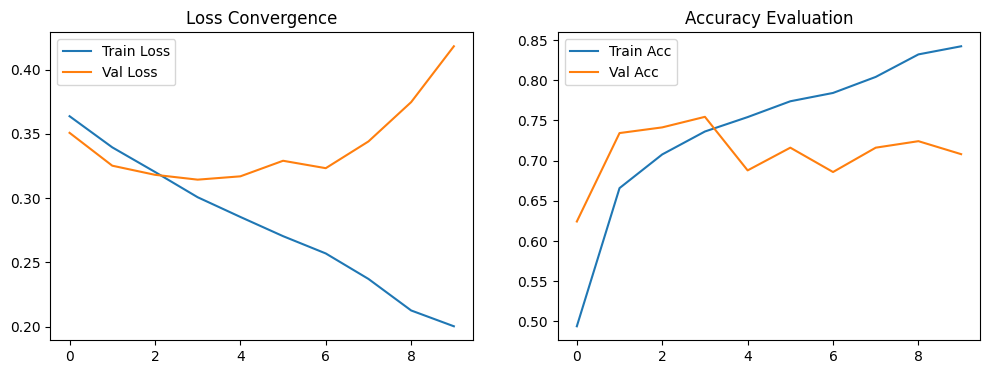

In [ ]:
# Cella 7: Training con Early Stopping e Scheduler

EPOCHS = 50
patience_early_stop = 6
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

print("Inizio Addestramento Pro...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Aggiorna lo scheduler dinamicamente
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoca {epoch+1:02d}/{EPOCHS} [LR: {current_lr:.5f}] -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience_early_stop:
        print(f"\n[Early Stopping] Interrotto all'epoca {epoch+1}!")
        break

model.load_state_dict(best_model_wts)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Convergence')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Evaluation')
plt.legend()
plt.show()

=== CLASSIFICATION REPORT ===
                      precision    recall  f1-score   support

    Contenuto (<80%)       0.54      0.57      0.55       263
Catastrofico (>=80%)       0.84      0.82      0.83       727

            accuracy                           0.75       990
           macro avg       0.69      0.69      0.69       990
        weighted avg       0.76      0.75      0.76       990

ROC-AUC Score: 0.7546



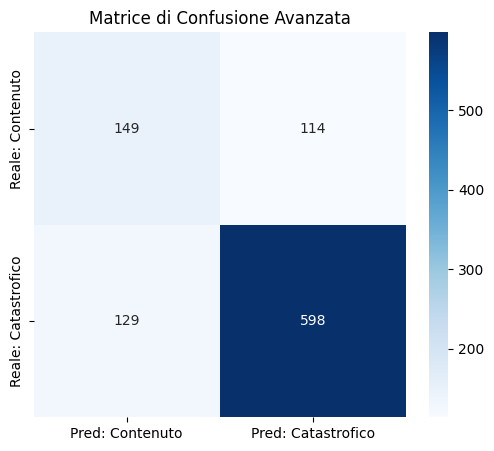

In [ ]:
# Cella 8: Valutazione
def evaluate_detailed(model, loader, device):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for tabular, texts, targets in loader:
            tabular, texts, targets = tabular.to(device), texts.to(device), targets.to(device)
            probs = torch.sigmoid(model(tabular, texts))
            preds = (probs >= 0.5).float()
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_prob = evaluate_detailed(model, val_loader, device)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Contenuto (<80%)", "Catastrofico (>=80%)"]))
print(f"ROC-AUC Score: {roc_auc_score(y_true, y_prob):.4f}\n")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Contenuto", "Pred: Catastrofico"],
            yticklabels=["Reale: Contenuto", "Reale: Catastrofico"])
plt.title('Matrice di Confusione Avanzata')
plt.show()

In [ ]:
# Cella 9: Test Pratico (Ora richiede anche il Mese!)
def predict_crash_severity(aboard_count, year, month, summary_text):
    model.eval()
    # Aggiunto il mese allo scaler
    scaled_numerical = scaler.transform(np.array([[aboard_count, year, month]]))
    tab_tensor = torch.tensor(scaled_numerical, dtype=torch.float32).to(device)

    encoded_text = text_to_indices(summary_text.lower(), vocab, MAX_LEN)
    txt_tensor = torch.tensor([encoded_text], dtype=torch.long).to(device)

    with torch.no_grad():
        probability = torch.sigmoid(model(tab_tensor, txt_tensor)).item()

    classification = "ALTAMENTE CATASTROFICO" if probability >= 0.5 else "PARZIALMENTE CONTENUTO"
    print(f"\nScenario [{month:02d}/{year}] {aboard_count} a bordo. Dinamica: '{summary_text}'")
    print(f"-> Probabilità Catastrofe: {probability:.2%} | Predizione: {classification}")

# Test 1: Inverno, molte persone, atterraggio di emergenza
predict_crash_severity(150, 2015, 12, "minor engine issues, successful emergency landing, minor injuries")
# Test 2: Estate, pioggia battente, schianto frontale
predict_crash_severity(80, 1978, 8, "crashed into a mountain during heavy rain, exploded on impact")


Scenario [12/2015] 150 a bordo. Dinamica: 'minor engine issues, successful emergency landing, minor injuries'
-> Probabilità Catastrofe: 36.33% | Predizione: PARZIALMENTE CONTENUTO

Scenario [08/1978] 80 a bordo. Dinamica: 'crashed into a mountain during heavy rain, exploded on impact'
-> Probabilità Catastrofe: 73.77% | Predizione: ALTAMENTE CATASTROFICO


In [ ]:
# Cella 10: Salvataggio per l'App
save_path = 'airplane_crash_pro_model.pth'

checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_kwargs': {
        'vocab_size': VOCAB_SIZE, 'embed_dim': EMBED_DIM,
        'lstm_hidden_dim': LSTM_HIDDEN, 'tabular_dim': TABULAR_DIM
    },
    'vocab': vocab, 'max_len': MAX_LEN,
    'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_
}

torch.save(checkpoint, save_path)
print(f"Modello PRO salvato con successo in: '{save_path}'!")

Modello PRO salvato con successo in: 'airplane_crash_pro_model.pth'!
